<a href="https://colab.research.google.com/github/aaryachauhan123/AI-ML-Learning/blob/main/DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

Reading Data Set

In [ ]:
data = pd.read_csv('/content/Renewable_Energy_Adoption.csv')
print(data.head())
# below this comment, we check if data has null values, it yes then we fill it with mean
# it is not required here, but it is good to check before starting
print(data.isnull().sum())
data.fillna(data.mean(), inplace=True)

   carbon_emissions  energy_output  ...  cost_efficiency  adoption
0        181.089042     128.286267  ...         0.732568         1
1        382.750007     672.769370  ...         2.891096         0
2        306.197880     382.920383  ...         2.932858         0
3        259.530469     557.713622  ...         3.368435         0
4        104.606524     916.809826  ...         3.767411         0

[5 rows x 5 columns]
carbon_emissions      0
energy_output         0
renewability_index    0
cost_efficiency       0
adoption              0
dtype: int64


In [ ]:
data.shape

(100, 5)

Defining x as input and y as output, and splitting the dataset into training and testing data

In [ ]:
x = data[['carbon_emissions', 'energy_output', 'renewability_index', 'cost_efficiency']]
y = data['adoption']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
#normalization of data set, so we best possible accuracy, it is not needed, but it's good to use
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

We will now declare model and give data to model

In [ ]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
#giving x_train and y_train to the model
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
#prediction based on the model by giving x_test
y_pred = model.predict(x_test)
print(y_pred)
#calculating accuracy using y_test and y_pred
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

[0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0]
Accuracy: 0.9


Confusion matrix for the predicted value, it shows at which part our model is confused.

Confusion Matrix:


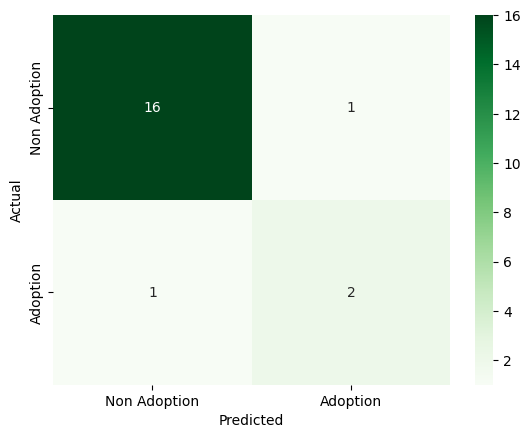

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap='Greens',
            xticklabels = ['Non Adoption', 'Adoption'],
            yticklabels = ['Non Adoption', 'Adoption'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
print("Confusion Matrix:")

Classification Report

precision : out of all predicted positive, how many are actual positive : TP/(TP+FP)

recall : out of all actual positive, how many are predicted positive : TP/(TP+FN)

f1 score : harmonic mean of both precision and recall : 2x(pxr)/(p+r)

In [ ]:
# Re-import classification_report in case it was overwritten
from sklearn.metrics import classification_report

clf_report_output = classification_report(y_test, y_pred, target_names = ['Non Adoption', 'Adoption'])
print("Classification Report:")
print(clf_report_output)

Classification Report:
              precision    recall  f1-score   support

Non Adoption       0.94      0.94      0.94        17
    Adoption       0.67      0.67      0.67         3

    accuracy                           0.90        20
   macro avg       0.80      0.80      0.80        20
weighted avg       0.90      0.90      0.90        20



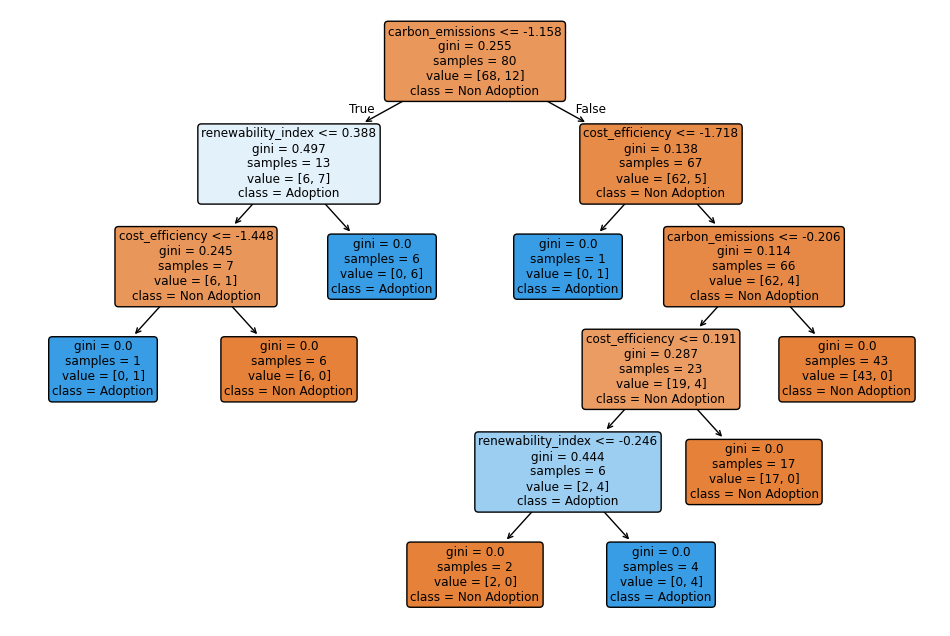

In [ ]:
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=x.columns, class_names=['Non Adoption', 'Adoption'], filled=True, rounded=True)
plt.savefig('dt1.png')
plt.show()